# Kafka and Spark Streaming Exercise — Tesla Stock & News

This notebook completes the Kafka and Spark Streaming part of the Tesla financial news and stock project.

Goal: split the merged Tesla stock/news dataset into JSON messages, send the messages to a Kafka topic, and process the topic with Spark Structured Streaming.

The streamed dataset combines all three project sources:

1. Tesla stock CSV file
2. Google News RSS web scraping
3. Alpha Vantage REST API news sentiment

**Important for submission:** run all cells either in the BDENG/JupyterHub environment or in the local Docker setup, check that the output cells are visible, and then export the notebook with output if a PDF is required.

Use Python, `pandas`, `kafka-python`, `pyspark` and Spark Structured Streaming to send messages to a Kafka topic and analyze them with Spark Streaming.

# Kafka

## Import necessary libraries

The imports are kept small. The optional install block only runs if `kafka-python` is missing in the notebook environment.

In [1]:
import json
import warnings
from datetime import datetime, timezone
from pathlib import Path

import pandas as pd

warnings.filterwarnings("ignore", category=DeprecationWarning)

try:
    from kafka import KafkaProducer, KafkaConsumer
    from kafka.admin import KafkaAdminClient, NewTopic
    from kafka.errors import TopicAlreadyExistsError
except ModuleNotFoundError:
    import sys
    import subprocess
    subprocess.check_call([sys.executable, "-m", "pip", "install", "kafka-python", "-q"])
    from kafka import KafkaProducer, KafkaConsumer
    from kafka.admin import KafkaAdminClient, NewTopic
    from kafka.errors import TopicAlreadyExistsError

## Load a dataset to stream

The merged result dataset is used because it combines the file-based stock data, scraped Google News data and Alpha Vantage REST API news data. Each row is converted into one JSON message.

In [2]:
DATA_PATH = Path("../data/results/tesla_stock_news_merged.csv")

if not DATA_PATH.exists():
    raise FileNotFoundError(f"Dataset not found: {DATA_PATH.resolve()}")

source_df = pd.read_csv(DATA_PATH)
source_df["Date"] = pd.to_datetime(source_df["Date"], errors="coerce").dt.strftime("%Y-%m-%d")

# Keep all available rows. The dataset is small, so this creates a controlled stream without excessive output.
message_df = source_df.copy()
message_df = message_df.astype(object).where(pd.notna(message_df), None)
messages = message_df.to_dict(orient="records")

print(f"Loaded {len(messages)} rows. Each row will be sent as one Kafka message.")
print("Total messages with stock data:", int(source_df["has_stock_data"].sum()) if "has_stock_data" in source_df else "n/a")
print("Total scraped news:", int(source_df["scraped_news_count"].sum()))
print("Total API news:", int(source_df["api_news_count"].sum()))
pd.DataFrame(messages).head(3)

Loaded 21 rows. Each row will be sent as one Kafka message.
Total messages with stock data: 0
Total scraped news: 99
Total API news: 50


,Date,Open,High,Low,Close,Volume,Daily_Return,Price_Range,MA_30,MA_100,...,scraped_titles,api_news_count,avg_api_sentiment,avg_tsla_sentiment,avg_tsla_relevance,api_sentiment_labels,tsla_sentiment_labels,api_titles,has_stock_data,total_news_count
0,2026-06-01,None,None,None,None,None,None,None,None,None,...,Reports of a Future SpaceX-Tesla Merger Are Pi...,0,0.0,0.0,0.0,None,None,None,False,1
1,2026-06-03,None,None,None,None,None,None,None,None,None,...,Tesla Stock Tests Short-Term Moving Averages A...,0,0.0,0.0,0.0,None,None,None,False,1
2,2026-06-04,None,None,None,None,None,None,None,None,None,...,Where Will Tesla Stock Be in 3 Years? - Yahoo ...,0,0.0,0.0,0.0,None,None,None,False,1


## Create a producer and stream the messages

The Kafka topic is created if it does not already exist. Only one summary line is printed to avoid excessive loop output.

In [3]:
# Cluster broker from Moodle. If you run a local Kafka setup, set KAFKA_BROKER=localhost:9092.
import os

KAFKA_BROKER = os.getenv("KAFKA_BROKER", "172.29.16.101:9092")
TOPIC = "group6_tesla_stock_news_stream_" + datetime.now(timezone.utc).strftime("%Y%m%d%H%M%S")

print("Kafka broker:", KAFKA_BROKER)
print("Kafka topic:", TOPIC)

# Create topic if possible. If topic creation is not allowed on the broker, the producer can still create it automatically on many Kafka setups.
try:
    admin_client = KafkaAdminClient(bootstrap_servers=KAFKA_BROKER, client_id="tesla_topic_admin")
    topic = NewTopic(name=TOPIC, num_partitions=1, replication_factor=1)
    try:
        admin_client.create_topics(new_topics=[topic], validate_only=False)
        print(f"Created Kafka topic: {TOPIC}")
    except TopicAlreadyExistsError:
        print(f"Kafka topic already exists: {TOPIC}")
    finally:
        admin_client.close()
except Exception as topic_error:
    print(f"Topic creation skipped or failed: {topic_error}")

producer = KafkaProducer(
    bootstrap_servers=KAFKA_BROKER,
    key_serializer=lambda key: str(key).encode("utf-8"),
    value_serializer=lambda value: json.dumps(value, default=str).encode("utf-8"),
)

for message in messages:
    producer.send(TOPIC, key=message.get("Date"), value=message)

producer.flush()
producer.close()

print(f"Sent {len(messages)} messages to Kafka topic '{TOPIC}'.")

Kafka broker: kafka:9092
Kafka topic: group6_tesla_stock_news_stream_20260701122335
Created Kafka topic: group6_tesla_stock_news_stream_20260701122335
Sent 21 messages to Kafka topic 'group6_tesla_stock_news_stream_20260701122335'.


## Create a consumer and check if the messages can be read

This is only a small sanity check. It reads and displays at most five messages, so the notebook output stays short.

In [4]:
consumer = KafkaConsumer(
    TOPIC,
    bootstrap_servers=KAFKA_BROKER,
    auto_offset_reset="earliest",
    enable_auto_commit=False,
    consumer_timeout_ms=5000,
    key_deserializer=lambda key: key.decode("utf-8") if key else None,
    value_deserializer=lambda value: json.loads(value.decode("utf-8")),
)

sample_messages = []
for kafka_message in consumer:
    sample_messages.append({
        "key": kafka_message.key,
        "Date": kafka_message.value.get("Date"),
        "Close": kafka_message.value.get("Close"),
        "Daily_Return": kafka_message.value.get("Daily_Return"),
        "scraped_news_count": kafka_message.value.get("scraped_news_count"),
        "api_news_count": kafka_message.value.get("api_news_count"),
    })
    if len(sample_messages) >= 5:
        break

consumer.close()

print(f"Read {len(sample_messages)} sample messages from Kafka.")
pd.DataFrame(sample_messages)

Read 5 sample messages from Kafka.


,key,Date,Close,Daily_Return,scraped_news_count,api_news_count
0,2026-06-01,2026-06-01,None,None,1,0
1,2026-06-03,2026-06-03,None,None,1,0
2,2026-06-04,2026-06-04,None,None,1,0
3,2026-06-05,2026-06-05,None,None,1,0
4,2026-06-08,2026-06-08,None,None,2,0


# Kafka and Spark Streaming

Spark acts as a Kafka consumer. The stream is parsed from JSON, transformed and aggregated into weekly summaries.

## Spark Context and Session

The log level is set to `ERROR` to prevent unnecessary Spark logs in the exported PDF.

In [5]:
import os
import shutil
from pathlib import Path

# Do not hardcode a Windows JAVA_HOME on Linux/JupyterHub.
# Only set it when this exact Windows path exists. Otherwise use the environment provided by the cluster/notebook image.
windows_java_home = Path(r"C:\Program Files\Eclipse Adoptium\jdk-17.0.15.6-hotspot")

if os.name == "nt" and windows_java_home.exists():
    os.environ["JAVA_HOME"] = str(windows_java_home)
    os.environ["PATH"] = str(windows_java_home / "bin") + os.pathsep + os.environ.get("PATH", "")
    print("Using Windows JAVA_HOME:", os.environ["JAVA_HOME"])
elif os.environ.get("JAVA_HOME"):
    print("Using existing JAVA_HOME:", os.environ["JAVA_HOME"])
elif shutil.which("java"):
    print("Using Java from PATH:", shutil.which("java"))
else:
    print("No JAVA_HOME found. On the BDENG cluster/JupyterHub this is usually preconfigured; otherwise install Java 17.")

Using Java from PATH: /usr/bin/java


In [6]:
from pyspark.sql import SparkSession
from pyspark.sql.functions import avg, col, count, from_json, lit, to_timestamp, when, window
from pyspark.sql.types import BooleanType, DoubleType, LongType, StringType, StructField, StructType

spark = (
    SparkSession.builder
    .appName("TeslaKafkaSparkStreaming")
    .master("local[*]")
    .config(
        "spark.jars.packages",
        "org.apache.spark:spark-sql-kafka-0-10_2.12:3.5.1"
    )
    .getOrCreate()
)

spark.sparkContext.setLogLevel("WARN")
spark

## Create a Spark DataFrame from a Kafka stream

The Kafka stream starts at the earliest available offset, so the messages sent above are included in the streaming query.

In [7]:
kafka_stream_df = (
    spark.readStream
    .format("kafka")
    .option("kafka.bootstrap.servers", KAFKA_BROKER)
    .option("subscribe", TOPIC)
    .option("startingOffsets", "earliest")
    .option("failOnDataLoss", "false")
    .load()
)

kafka_stream_df.printSchema()

root
 |-- key: binary (nullable = true)
 |-- value: binary (nullable = true)
 |-- topic: string (nullable = true)
 |-- partition: integer (nullable = true)
 |-- offset: long (nullable = true)
 |-- timestamp: timestamp (nullable = true)
 |-- timestampType: integer (nullable = true)



## Convert the binary Kafka data to strings

Kafka stores keys and values as binary data. For JSON parsing, the value column is converted to a string.

In [8]:
json_stream_df = kafka_stream_df.selectExpr(
    "CAST(key AS STRING) AS kafka_key",
    "CAST(value AS STRING) AS json_value",
    "timestamp AS kafka_timestamp"
)

json_stream_df.printSchema()

root
 |-- kafka_key: string (nullable = true)
 |-- json_value: string (nullable = true)
 |-- kafka_timestamp: timestamp (nullable = true)



## Create a structured schema for the streamed data

The schema matches the columns of `tesla_stock_news_merged.csv`. After parsing, additional columns for event time, total news count and return direction are created.

In [9]:
tesla_schema = StructType([
    StructField("Date", StringType(), True),
    StructField("Open", DoubleType(), True),
    StructField("High", DoubleType(), True),
    StructField("Low", DoubleType(), True),
    StructField("Close", DoubleType(), True),
    StructField("Volume", LongType(), True),
    StructField("Daily_Return", DoubleType(), True),
    StructField("Price_Range", DoubleType(), True),
    StructField("MA_30", DoubleType(), True),
    StructField("MA_100", DoubleType(), True),
    StructField("scraped_news_count", DoubleType(), True),
    StructField("scraped_sources", StringType(), True),
    StructField("scraped_titles", StringType(), True),
    StructField("api_news_count", DoubleType(), True),
    StructField("avg_api_sentiment", DoubleType(), True),
    StructField("avg_tsla_sentiment", DoubleType(), True),
    StructField("avg_tsla_relevance", DoubleType(), True),
    StructField("api_sentiment_labels", StringType(), True),
    StructField("tsla_sentiment_labels", StringType(), True),
    StructField("api_titles", StringType(), True),
    StructField("has_stock_data", BooleanType(), True),
    StructField("total_news_count", DoubleType(), True),
])

parsed_stream_df = (
    json_stream_df
    .select(
        col("kafka_key"),
        from_json(col("json_value"), tesla_schema).alias("data"),
        col("kafka_timestamp"),
    )
    .select("kafka_key", "data.*", "kafka_timestamp")
    .withColumn("event_time", to_timestamp(col("Date"), "yyyy-MM-dd"))
    .withColumn(
        "return_direction",
        when(col("has_stock_data") == False, lit("no_stock_data"))
        .when(col("Daily_Return") > 0, lit("positive"))
        .when(col("Daily_Return") < 0, lit("negative"))
        .otherwise(lit("neutral"))
    )
)

parsed_stream_df.printSchema()

root
 |-- kafka_key: string (nullable = true)
 |-- Date: string (nullable = true)
 |-- Open: double (nullable = true)
 |-- High: double (nullable = true)
 |-- Low: double (nullable = true)
 |-- Close: double (nullable = true)
 |-- Volume: long (nullable = true)
 |-- Daily_Return: double (nullable = true)
 |-- Price_Range: double (nullable = true)
 |-- MA_30: double (nullable = true)
 |-- MA_100: double (nullable = true)
 |-- scraped_news_count: double (nullable = true)
 |-- scraped_sources: string (nullable = true)
 |-- scraped_titles: string (nullable = true)
 |-- api_news_count: double (nullable = true)
 |-- avg_api_sentiment: double (nullable = true)
 |-- avg_tsla_sentiment: double (nullable = true)
 |-- avg_tsla_relevance: double (nullable = true)
 |-- api_sentiment_labels: string (nullable = true)
 |-- tsla_sentiment_labels: string (nullable = true)
 |-- api_titles: string (nullable = true)
 |-- has_stock_data: boolean (nullable = true)
 |-- total_news_count: double (nullable = tr

## Create a DataFrame grouped by a time window

The stream is aggregated into seven-day windows. For each window and return direction, the number of messages, average return, average close price, average volume and average news count are calculated.

In [10]:
windowed_stream_df = (
    parsed_stream_df
    .withWatermark("event_time", "14 days")
    .groupBy(window(col("event_time"), "7 days"), col("return_direction"))
    .agg(
        count("*").alias("message_count"),
        avg("Daily_Return").alias("avg_daily_return"),
        avg("Close").alias("avg_close"),
        avg("Volume").alias("avg_volume"),
        avg("total_news_count").alias("avg_total_news_count"),
    )
)

## Create a query stream of the DataFrame

The output is written to a memory table. `trigger(once=True)` processes the available Kafka messages once and then stops, which is suitable for a controlled exercise notebook.

In [11]:
# Stop an old query with the same name if the cell is rerun.
for active_query in spark.streams.active:
    if active_query.name == "tesla_stream_summary":
        active_query.stop()

query = (
    windowed_stream_df.writeStream
    .format("memory")
    .queryName("tesla_stream_summary")
    .outputMode("complete")
    .trigger(once=True)
    .start()
)

finished = query.awaitTermination(timeout=60)
if not finished:
    query.stop()
    print("Streaming query timed out after 60 seconds and was stopped. Check broker/topic connectivity.")

summary_spark_df = spark.sql("""
    SELECT
        window.start AS window_start,
        window.end AS window_end,
        return_direction,
        message_count,
        ROUND(avg_daily_return, 5) AS avg_daily_return,
        ROUND(avg_close, 2) AS avg_close,
        ROUND(avg_volume, 0) AS avg_volume,
        ROUND(avg_total_news_count, 2) AS avg_total_news_count
    FROM tesla_stream_summary
    ORDER BY window_start, return_direction
""")

summary_spark_df.show(20, truncate=False)

+-------------------+-------------------+----------------+-------------+----------------+---------+----------+--------------------+
|window_start       |window_end         |return_direction|message_count|avg_daily_return|avg_close|avg_volume|avg_total_news_count|
+-------------------+-------------------+----------------+-------------+----------------+---------+----------+--------------------+
|2026-05-28 00:00:00|2026-06-04 00:00:00|no_stock_data   |2            |NULL            |NULL     |NULL      |1.0                 |
|2026-06-04 00:00:00|2026-06-11 00:00:00|no_stock_data   |5            |NULL            |NULL     |NULL      |9.8                 |
|2026-06-11 00:00:00|2026-06-18 00:00:00|no_stock_data   |4            |NULL            |NULL     |NULL      |4.0                 |
|2026-06-18 00:00:00|2026-06-25 00:00:00|no_stock_data   |4            |NULL            |NULL     |NULL      |2.5                 |
|2026-06-25 00:00:00|2026-07-02 00:00:00|no_stock_data   |6            |NULL

## Export the processed data as a Pandas DataFrame and visualize it

The aggregated streaming result is saved as a CSV file for later presentation and visualized with a compact chart.

In [12]:
import matplotlib.pyplot as plt

summary_pd = summary_spark_df.toPandas()

output_path = Path("../data/results/tesla_kafka_stream_summary.csv")
output_path.parent.mkdir(parents=True, exist_ok=True)
summary_pd.to_csv(output_path, index=False)

print(f"Saved {len(summary_pd)} aggregated rows to {output_path}")
summary_pd.head(10)

Saved 5 aggregated rows to ../data/results/tesla_kafka_stream_summary.csv


,window_start,window_end,return_direction,message_count,avg_daily_return,avg_close,avg_volume,avg_total_news_count
0,2026-05-28,2026-06-04,no_stock_data,2,NaN,NaN,NaN,1.0
1,2026-06-04,2026-06-11,no_stock_data,5,NaN,NaN,NaN,9.8
2,2026-06-11,2026-06-18,no_stock_data,4,NaN,NaN,NaN,4.0
3,2026-06-18,2026-06-25,no_stock_data,4,NaN,NaN,NaN,2.5
4,2026-06-25,2026-07-02,no_stock_data,6,NaN,NaN,NaN,12.0


## Visualization: streaming result

This chart shows how many streamed messages occurred per seven-day window and return direction.

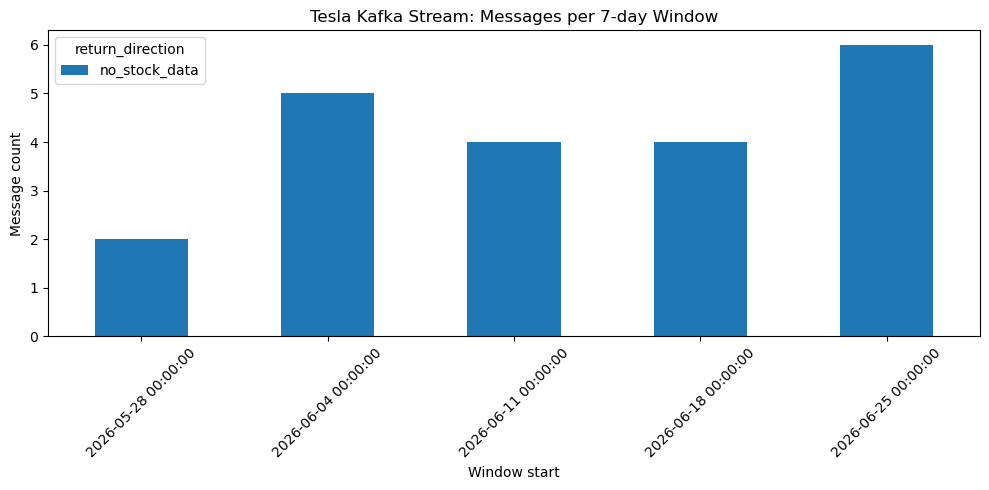

In [13]:
if summary_pd.empty:
    print("No streaming summary available. Check Kafka topic, broker and Spark Kafka connector.")
else:
    plot_df = summary_pd.copy()
    plot_df["window_start"] = pd.to_datetime(plot_df["window_start"])
    pivot_df = plot_df.pivot_table(
        index="window_start",
        columns="return_direction",
        values="message_count",
        aggfunc="sum",
        fill_value=0,
    )

    ax = pivot_df.plot(kind="bar", figsize=(10, 5))
    ax.set_title("Tesla Kafka Stream: Messages per 7-day Window")
    ax.set_xlabel("Window start")
    ax.set_ylabel("Message count")
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

## Short conclusion

The merged Tesla dataset was split into individual JSON messages and written to a Kafka topic. Spark Structured Streaming consumed the Kafka topic, parsed the messages with a defined schema and created weekly aggregates. This demonstrates the complete pipeline required for the exercise: dataset → messages → Kafka topic → Spark Streaming processing → result file and visualization.